In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, multivariate_normal
from timeit import default_timer as timer

data=np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/olympic100m.csv', header=None))
t=data[:,1]; X=np.transpose(np.array([np.ones(len(data)),data[:,0]])); 
sig=np.sqrt(5/100); mu0=[0,0]; SIG0=[[100,0], [0,5]]; xnew=[1,29]
SIGw=np.linalg.inv(X.T@X/sig**2+np.linalg.inv(SIG0))
muw=SIGw@(X.T@t/sig**2+np.linalg.inv(SIG0)@mu0)

start = timer()
w0=np.linspace(10.5,11.5,100);d0=(w0[-1]-w0[0])/(len(w0)-1)
w1=np.linspace(-0.07,-0.03,100);d1=(w1[-1]-w1[0])/(len(w1)-1)
tnew=np.linspace(8.5,10.5,10);dt=(tnew[-1]-tnew[0])/(len(tnew)-1)
w=np.array([w0,w1]).T
posterior=np.array([multivariate_normal.pdf([w0[i],w1[j]], muw, SIGw) for i in range(len(w0)) for j in range(len(w1))])
len(posterior)
sum(posterior*d0*d1)
predictive=[sum([norm.pdf(tnew[k], xnew@np.array([w0[i],w1[j]]), sig)*multivariate_normal.pdf([w0[i],w1[j]], muw, SIGw) for i in range(len(w0)) for j in range(len(w1))]) for k in range(len(tnew))]
sum(np.array(predictive)*d0*d1*dt)
print(timer()-start)

plt.plot(tnew, predictive)
plt.show()
tnew[predictive==max(predictive)]
np.array(xnew)@muw

LinAlgError: When `allow_singular is False`, the input matrix must be symmetric positive definite.

The area below the predictive is 0.9996294959368075, so it is a probability!
The time spent is 2261.659813541
9.595109510951096


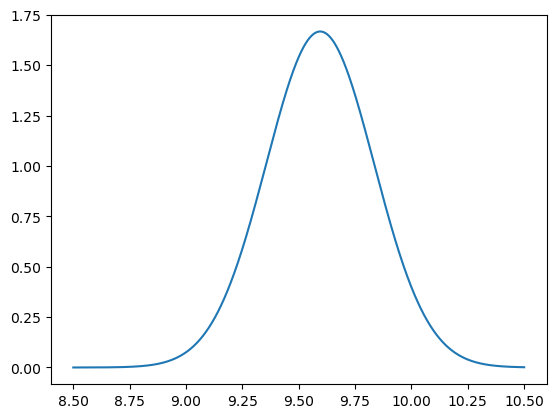

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from timeit import default_timer as timer 

data=np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/olympic100m-2.csv', header=None))
t=data[:,1]; X=np.transpose(np.array([np.ones(len(data)),data[:,0]])); 
sig=np.sqrt(5/100); mu0=[0,0]; SIG0=[[100,0], [0,5]]; xnew=[1,29]
SIGw=np.linalg.inv(X.T@X/sig**2+np.linalg.inv(SIG0))
muw=SIGw@(X.T@t/sig**2+np.linalg.inv(SIG0)@mu0)
start = timer()
w0=np.linspace(10.5,11.5,100);d0=(w0[-1]-w0[0])/(len(w0)-1)
w1=np.linspace(-0.07,-0.03,100);d1=(w1[-1]-w1[0])/(len(w1)-1)
tnew=np.linspace(8.5,10.5,10000);dt=(tnew[-1]-tnew[0])/(len(tnew)-1)
posterior=np.array([(2*np.pi)**(-1) * np.linalg.det(SIGw)**(-1/2) * np.exp(-1/2*(np.array([w0[i],w1[j]])-muw)@np.linalg.inv(SIGw)@(np.array([w0[i],w1[j]])-muw).T) for i in range(len(w0)) for j in range(len(w1))])
len(posterior)
sum(posterior*d0*d1)
lkh=np.array([(2*np.pi)**(-1/2) * sig**(-1) * np.exp(-1/2*((tnew[k]-xnew@np.array([w0[i],w1[j]]))/sig)**2) for k in range(len(tnew)) for i in range(len(w0)) for j in range(len(w1))])
len(lkh)
sum(lkh*d0*d1*dt)
predictive=np.array([(2*np.pi)**(-1) * np.linalg.det(SIGw)**(-1/2) * np.exp(-1/2*(np.array([w0[i],w1[j]])-muw)@np.linalg.inv(SIGw)@(np.array([w0[i],w1[j]])-muw).T) * (2*np.pi)**(-1/2) * sig**(-1) * np.exp(-1/2*((tnew[k]-xnew@np.array([w0[i],w1[j]]))/sig)**2) for k in range(len(tnew)) for i in range(len(w0)) for j in range(len(w1))])
print("The area below the predictive is "+str(sum(predictive*d0*d1*dt))+", so it is a probability!")
predpdf=[np.sum([(2*np.pi)**(-1) * np.linalg.det(SIGw)**(-1/2) * np.exp(-1/2*(np.array([w0[i],w1[j]])-muw)@np.linalg.inv(SIGw)@(np.array([w0[i],w1[j]])-muw).T) * (2*np.pi)**(-1/2) * sig**(-1) * np.exp(-1/2*((tnew[k]-xnew@np.array([w0[i],w1[j]]))/sig)**2) for i in range(len(w0)) for j in range(len(w1))])*d0*d1 for k in range(len(tnew))]
print("The time spent is "+str(timer()-start))

# find highest point's X
idx_peak = np.argmax(predpdf)
x_peak = tnew[idx_peak]
print(x_peak)
plt.plot(tnew, predpdf)
plt.show()
